In [1]:
import pandas as pd

print("Data loading...")
X_train = pd.read_csv('processed_data/X_train_final.csv')
y_train = pd.read_csv('processed_data/y_train_final.csv')['loan_status']

X_valid = pd.read_csv('processed_data/X_valid_final.csv')
y_valid = pd.read_csv('processed_data/y_valid_final.csv')['loan_status']

X_test = pd.read_csv('processed_data/X_test_final.csv')
y_test = pd.read_csv('processed_data/y_test_final.csv')['loan_status']

print(f"Data size - Train: {X_train.shape}")
print(f"Data size - Valid: {X_valid.shape}")
print(f"Data size - Test: {X_test.shape}")

Data loading...
Data size - Train: (35660, 20)
Data size - Valid: (4887, 20)
Data size - Test: (4888, 20)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

def evaluate_model(model, X_train, y_train, X_eval, y_eval, model_name, fit_model=True):
    """
    Hàm này giúp huấn luyện, dự đoán và in ra các chỉ số đánh giá cho mô hình.
    X_eval, y_eval: Có thể là tập Valid (để tinh chỉnh) hoặc tập Test (để thi thật).
    """
    print(f"\n{'='*50}")
    print(f"--- ĐÁNH GIÁ MÔ HÌNH: {model_name} ---")
    print(f"{'='*50}")
    
    # Training nếu có yêu cầu
    if fit_model:
        model.fit(X_train, y_train)
    
    # Dự đoán trên tập Đánh giá
    y_pred = model.predict(X_eval)
    y_pred_proba = model.predict_proba(X_eval)[:, 1] # Lấy xác suất rơi vào Nợ xấu (Class 1)
    
    # Classification Report
    print("\n1. BÁO CÁO PHÂN LOẠI (Classification Report):")
    print(classification_report(y_eval, y_pred, target_names=['Trả đủ (0)', 'Nợ xấu (1)']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Đoán: Trả đủ', 'Đoán: Nợ xấu'],
                yticklabels=['Thật: Trả đủ', 'Thật: Nợ xấu'])
    plt.title(f'Ma trận nhầm lẫn - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Mô hình Dự đoán')
    plt.show()
    
    # Tính ROC-AUC
    auc_score = roc_auc_score(y_eval, y_pred_proba)
    print(f"\n=> ĐIỂM ROC-AUC: {auc_score:.4f}")
    
    return y_pred_proba, auc_score


--- ĐÁNH GIÁ MÔ HÌNH: Logistic Regression ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.92      0.83      0.88      3821
  Nợ xấu (1)       0.56      0.75      0.64      1066

    accuracy                           0.82      4887
   macro avg       0.74      0.79      0.76      4887
weighted avg       0.84      0.82      0.82      4887



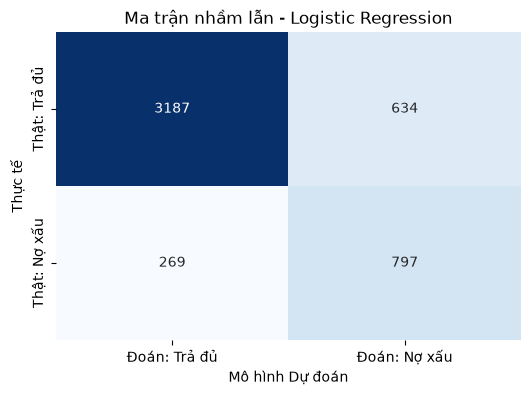


=> ĐIỂM ROC-AUC: 0.8633


In [3]:
# LOGISTIC REGRESSION (BASELINE)
from sklearn.linear_model import LogisticRegression
# Khởi tạo (Tăng max_iter để đảm bảo thuật toán hội tụ)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# đánh giá
proba_logreg, auc_logreg = evaluate_model(
    model=log_reg, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_valid, y_eval=y_valid, 
    model_name="Logistic Regression"
)


--- ĐÁNH GIÁ MÔ HÌNH: XGBoost Classifier (Tập Validation) ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.92      0.98      0.95      3821
  Nợ xấu (1)       0.91      0.71      0.80      1066

    accuracy                           0.92      4887
   macro avg       0.92      0.84      0.87      4887
weighted avg       0.92      0.92      0.92      4887



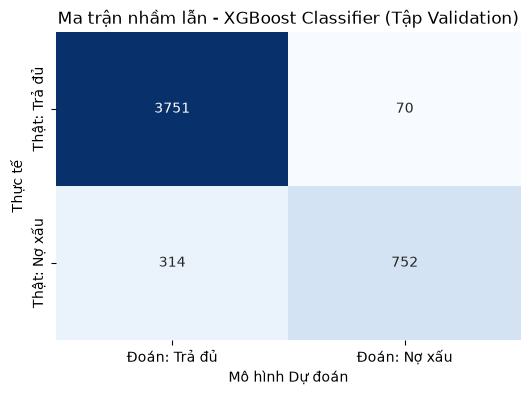


=> ĐIỂM ROC-AUC: 0.9337


In [4]:
# XGBOOST (NÂNG CAO)
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,      # Số lượng cây quyết định
    learning_rate=0.1,     # Tốc độ học
    max_depth=5,           # Độ sâu tối đa của cây (tránh overfitting)
    random_state=42,
    eval_metric='logloss'  # Hàm mất mát cho bài toán phân loại
)

# Gọi hàm đánh giá trên tập Validation
proba_xgb, auc_xgb = evaluate_model(
    model=xgb_model, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_valid, y_eval=y_valid, 
    model_name="XGBoost Classifier (Tập Validation)"
)


--- SO SÁNH TỔNG THỂ HAI THUẬT TOÁN (TẬP VALIDATION) ---


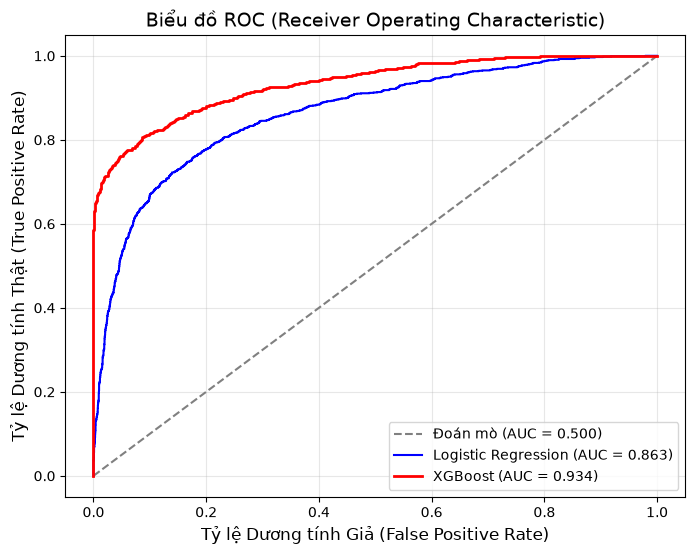

In [5]:
import matplotlib.pyplot as plt
print("\n--- SO SÁNH TỔNG THỂ HAI THUẬT TOÁN (TẬP VALIDATION) ---")

# Tính toán các điểm trên đường cong ROC cho cả 2 mô hình
fpr_logreg, tpr_logreg, _ = roc_curve(y_valid, proba_logreg)
fpr_xgb, tpr_xgb, _ = roc_curve(y_valid, proba_xgb)

plt.figure(figsize=(8, 6))
# Vẽ đường Baseline ngẫu nhiên (50/50)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Đoán mò (AUC = 0.500)')

# Vẽ đường Logistic Regression
plt.plot(fpr_logreg, tpr_logreg, color='blue', 
         label=f'Logistic Regression (AUC = {auc_logreg:.3f})')

# Vẽ đường XGBoost
plt.plot(fpr_xgb, tpr_xgb, color='red', linewidth=2,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.title('Biểu đồ ROC (Receiver Operating Characteristic)', fontsize=14)
plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính Thật (True Positive Rate)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


--- KIỂM TRA TRÊN TẬP TEST ---
Sau khi đối chiếu 2 models, XGBoost là model hiệu quả hơn.

--- ĐÁNH GIÁ MÔ HÌNH: XGBoost Classifier ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.92      0.98      0.95      3822
  Nợ xấu (1)       0.91      0.68      0.78      1066

    accuracy                           0.92      4888
   macro avg       0.92      0.83      0.87      4888
weighted avg       0.92      0.92      0.91      4888



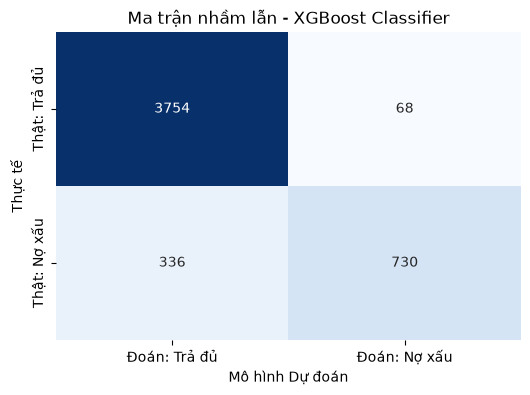


=> ĐIỂM ROC-AUC: 0.9248


In [6]:
# ĐÁNH GIÁ TRÊN TẬP TEST (BÀI THI CUỐI CÙNG)
print("\n" + "="*50)
print("--- KIỂM TRA TRÊN TẬP TEST ---")
print("="*50)
print("Sau khi đối chiếu 2 models, XGBoost là model hiệu quả hơn.")

# Đánh giá lại mô hình XGBoost trên tập Test
proba_test_xgb, auc_test_xgb = evaluate_model(
    model=xgb_model, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_test, y_eval=y_test, 
    model_name="XGBoost Classifier",
    fit_model=False # Tắt chế độ fit để giữ nguyên trọng số đã học
)

--- TỔNG HỢP, TRỰC QUAN HÓA VÀ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ---


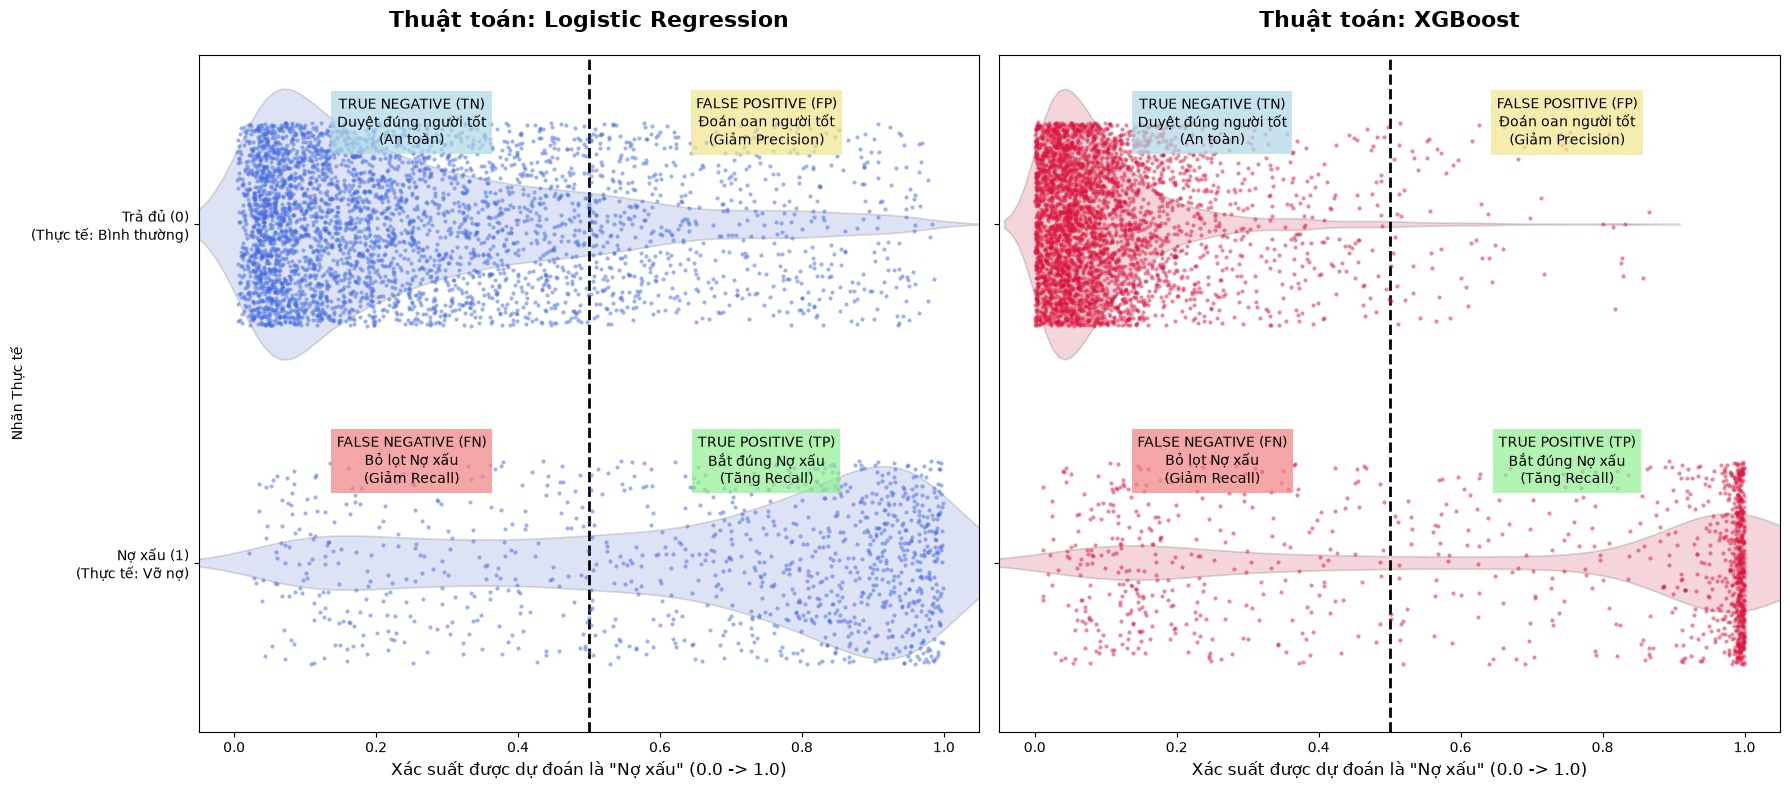


BẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ THỰC TẾ TRÊN TẬP TEST:



,Thuật toán,Accuracy,Precision (Nợ xấu),Recall (Nợ xấu),F1-Score,ROC-AUC
0,Logistic Regression (Baseline),81.46%,55.63%,74.11%,0.6356,0.8546
1,XGBoost Classifier (Nâng cao),91.73%,91.48%,68.48%,0.7833,0.9248


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("=====================================================================")
print("--- TỔNG HỢP, TRỰC QUAN HÓA VÀ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ---")
print("=====================================================================")

# 1. LẤY XÁC SUẤT DỰ ĐOÁN CHUẨN XÁC TRÊN TẬP TEST (Dạng số thập phân liên tục)
proba_test_logreg = log_reg.predict_proba(X_test)[:, 1]
proba_test_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Ép kiểu dữ liệu y_test về mảng số nguyên nhị phân chuẩn (0 và 1) để tránh lỗi định dạng từ Pandas
y_test_bin = np.array(y_test).astype(int)

# TỰ ĐỘNG CHUYỂN ĐỔI XÁC SUẤT THÀNH NHÃN NHỊ PHÂN CỨNG (0 HOẶC 1) QUA NGƯỠNG THRESHOLD = 0.5
y_pred_logreg_bin = (proba_test_logreg >= 0.5).astype(int)
y_pred_xgb_bin = (proba_test_xgb >= 0.5).astype(int)

# 2. TẠO BẢNG DỮ LIỆU PHỤC VỤ VẼ BIỂU ĐỒ (Sử dụng xác suất liên tục cho trục X)
df_results = pd.DataFrame({
    'Thực tế': y_test_bin,
    'Logistic Regression': proba_test_logreg,
    'XGBoost': proba_test_xgb
})

# Chuyển đổi nhãn lớp thực tế để biểu thị rõ ràng trên trục Y
df_results['Nhãn Thực tế'] = df_results['Thực tế'].map({0: 'Trả đủ (0)\n(Thực tế: Bình thường)', 
                                                        1: 'Nợ xấu (1)\n(Thực tế: Vỡ nợ)'})

# 3. THIẾT LẬP KHUNG VẼ 2 BIỂU ĐỒ NẰM NGANG ĐỐI CHIẾU (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

models = ['Logistic Regression', 'XGBoost']
colors = ['royalblue', 'crimson']

for i, model in enumerate(models):
    # Vẽ lớp Violin Plot làm nền mờ thể hiện mật độ phân bố của đám đông
    sns.violinplot(data=df_results, x=model, y='Nhãn Thực tế', 
                   inner=None, color=colors[i], alpha=0.2, ax=axes[i], orient='h')
    
    # Vẽ lớp Strip Plot mô tả từng điểm dữ liệu khách hàng đơn lẻ có độ rung (Jitter)
    sns.stripplot(data=df_results, x=model, y='Nhãn Thực tế', 
                  color=colors[i], alpha=0.5, size=3, jitter=0.3, ax=axes[i], orient='h')
    
    # Vẽ vạch ranh giới quyết định phân loại tại ngưỡng xác suất quyết định 0.5
    axes[i].axvline(0.5, color='black', linestyle='--', linewidth=2)
    
    # Định dạng các thông số hiển thị cho từng biểu đồ nhánh
    axes[i].set_title(f'Thuật toán: {model}', fontsize=16, fontweight='bold', pad=20)
    axes[i].set_xlabel('Xác suất được dự đoán là "Nợ xấu" (0.0 -> 1.0)', fontsize=12)
    axes[i].set_xlim(-0.05, 1.05)
    
    # --- THÊM NHÃN CHÚ THÍCH GIẢI THÍCH CHỈ SỐ LÊN CÁC VÙNG PHÂN TỨ ---
    # Góc phải của dòng Nợ xấu (Thật: 1, Đoán: >= 0.5) -> Đúng mục tiêu phân loại
    axes[i].text(0.75, 0.7, 'TRUE POSITIVE (TP)\nBắt đúng Nợ xấu\n(Tăng Recall)', 
                 ha='center', va='center', bbox=dict(facecolor='lightgreen', alpha=0.7, edgecolor='none'))
    
    # Góc trái của dòng Nợ xấu (Thật: 1, Đoán: < 0.5) -> Bỏ lọt đối tượng rủi ro
    axes[i].text(0.25, 0.7, 'FALSE NEGATIVE (FN)\nBỏ lọt Nợ xấu\n(Giảm Recall)', 
                 ha='center', va='center', bbox=dict(facecolor='lightcoral', alpha=0.7, edgecolor='none'))
    
    # Góc phải của dòng Trả đủ (Thật: 0, Đoán: >= 0.5) -> Đánh giá sai lệch khách hàng tốt
    axes[i].text(0.75, -0.3, 'FALSE POSITIVE (FP)\nĐoán oan người tốt\n(Giảm Precision)', 
                 ha='center', va='center', bbox=dict(facecolor='khaki', alpha=0.7, edgecolor='none'))
    
    # Góc trái của dòng Trả đủ (Thật: 0, Đoán: < 0.5) -> Xác nhận chính xác điểm an toàn
    axes[i].text(0.25, -0.3, 'TRUE NEGATIVE (TN)\nDuyệt đúng người tốt\n(An toàn)', 
                 ha='center', va='center', bbox=dict(facecolor='lightblue', alpha=0.7, edgecolor='none'))

plt.ylabel('')
plt.tight_layout()
plt.show()

# 4. IN BẢNG BÁO CÁO THỐNG KÊ BẰNG DATAFRAME TỪ KẾT QUẢ HUẤN LUYỆN THỰC TẾ
# Các chỉ số nhị phân sử dụng biến nhãn cứng dạng int (*_bin), chỉ riêng ROC-AUC sử dụng biến xác suất liên tục (*_test)
metrics_logreg = {
    "Thuật toán": "Logistic Regression (Baseline)",
    "Accuracy": f"{accuracy_score(y_test_bin, y_pred_logreg_bin):.2%}",
    "Precision (Nợ xấu)": f"{precision_score(y_test_bin, y_pred_logreg_bin):.2%}",
    "Recall (Nợ xấu)": f"{recall_score(y_test_bin, y_pred_logreg_bin):.2%}",
    "F1-Score": f"{f1_score(y_test_bin, y_pred_logreg_bin):.4f}",
    "ROC-AUC": f"{roc_auc_score(y_test_bin, proba_test_logreg):.4f}"
}

metrics_xgb = {
    "Thuật toán": "XGBoost Classifier (Nâng cao)",
    "Accuracy": f"{accuracy_score(y_test_bin, y_pred_xgb_bin):.2%}",
    "Precision (Nợ xấu)": f"{precision_score(y_test_bin, y_pred_xgb_bin):.2%}",
    "Recall (Nợ xấu)": f"{recall_score(y_test_bin, y_pred_xgb_bin):.2%}",
    "F1-Score": f"{f1_score(y_test_bin, y_pred_xgb_bin):.4f}",
    "ROC-AUC": f"{roc_auc_score(y_test_bin, proba_test_xgb):.4f}"
}

df_report = pd.DataFrame([metrics_logreg, metrics_xgb])

print("\nBẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ THỰC TẾ TRÊN TẬP TEST:\n")
from IPython.display import display
display(df_report)